# Orbit Wars - Exploratory Data Analysis

This notebook provides a hands-on look at the `kaggle_environments` **orbit_wars**
environment: how the map is generated, how games unfold, how fleet speed scales
with fleet size, when comets appear, and how the reference `random` and `sniper`
agents behave. Every analytical cell reruns the environment from scratch with
fixed seeds, so the notebook is deterministic end-to-end. The goal is to surface
concrete, quantitative observations that should inform agent design for the
competition.


## 1. Setup and environment inspection

Import the environment and a couple of reference agents shipped with this repo, make a two-player game, and print the specification.

In [1]:
%matplotlib inline
import os
import sys
import math
import time
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import kaggle_environments
from kaggle_environments.envs.orbit_wars.orbit_wars import (
    Planet, Fleet, CENTER, ROTATION_RADIUS_LIMIT,
)
from agents import Agent

print("kaggle_environments version:", kaggle_environments.__version__)
print("repo root on sys.path:", REPO_ROOT)
print("agents available:", Agent("random").id, "|", Agent("sniper").id)


Loading environment cabt failed: dlopen(/Users/hirotakaishihara/Library/Python/3.11/lib/python/site-packages/kaggle_environments/envs/cabt/cg/libcg.so, 0x0006): tried: '/Users/hirotakaishihara/Library/Python/3.11/lib/python/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (slice is not valid mach-o file), '/System/Volumes/Preboot/Cryptexes/OS/Users/hirotakaishihara/Library/Python/3.11/lib/python/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (no such file), '/Users/hirotakaishihara/Library/Python/3.11/lib/python/site-packages/kaggle_environments/envs/cabt/cg/libcg.so' (slice is not valid mach-o file)


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 16.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess


...

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_repeated_poker


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_python_repeated_pokerkit


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: OpenSpiel games skipped: 1.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    snake


kaggle_environments version: 1.28.0
repo root on sys.path: /Users/agent/dev/kaggle-orbit-wars
agents available: random | sniper


In [2]:
env = kaggle_environments.make("orbit_wars", debug=False)
print("env.name            :", env.name)
print("env.version         :", env.version)
print("spec.agents         :", env.specification.agents)
print("configuration       :", dict(env.configuration))
print("CENTER              :", CENTER)
print("ROTATION_RADIUS_LIMIT:", ROTATION_RADIUS_LIMIT)


env.name            : orbit_wars
env.version         : 1.0.9
spec.agents         : [2, 4]
configuration       : {'episodeSteps': 500, 'actTimeout': 1, 'runTimeout': 1200, 'agentTimeout': 2, 'shipSpeed': 6.0, 'cometSpeed': 4.0}
CENTER              : 50.0
ROTATION_RADIUS_LIMIT: 50.0


In [3]:
# Seed a single game to peek at the observation schema.
random.seed(0)
np.random.seed(0)


def _noop(obs):
    return []


_probe = kaggle_environments.make("orbit_wars", debug=False, configuration={"episodeSteps": 2})
_probe.run([_noop, _noop])
obs = _probe.steps[1][0].observation
print("observation keys   :", list(obs.keys()))
print("n planets (t=1)    :", len(obs["planets"]))
print("planet tuple[0]    :", obs["planets"][0])
print("Planet named       :", Planet(*obs["planets"][0]))
print("angular_velocity   :", obs["angular_velocity"])
print("comet_planet_ids   :", obs["comet_planet_ids"])


observation keys   : ['remainingOverageTime', 'step', 'planets', 'fleets', 'player', 'angular_velocity', 'initial_planets', 'next_fleet_id', 'comets', 'comet_planet_ids']
n planets (t=1)    : 32
planet tuple[0]    : [0, 0, 97.0465769907226, 70.2638979925115, 1.0, 10, 1]
Planet named       : Planet(id=0, owner=0, x=97.0465769907226, y=70.2638979925115, radius=1.0, ships=10, production=1)
angular_velocity   : 0.046110546288126206
comet_planet_ids   : []


**Notes.** `env.steps[0]` is an empty pre-reset placeholder (no planets yet); the first real state is at `t=1`. Every planet is a 7-tuple `(id, owner, x, y, radius, ships, production)` and the `Planet` named tuple from the env module gives human-friendly field access. `angular_velocity` is the per-game rotation rate for orbiting planets, and `comet_planet_ids` starts empty because comets are not spawned until step 50.

## 2. Map generation statistics

The map is regenerated on every `env.reset()`. To build distributions we spin up
50 two-player games and collect the `t=1` observation -- we don't need to actually
play the game to look at the board.


In [4]:
N_MAP_GAMES = 50


def sample_initial_state(n_games=N_MAP_GAMES, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    rows_planets = []
    per_game = []
    for g in range(n_games):
        env_g = kaggle_environments.make("orbit_wars", debug=False, configuration={"episodeSteps": 2})
        env_g.run([_noop, _noop])
        obs_g = env_g.steps[1][0].observation
        planets = obs_g["planets"]
        cpi = set(obs_g.get("comet_planet_ids", []) or [])
        per_game.append({
            "game": g,
            "n_planets": len(planets),
            "n_comets_t1": len(cpi),
            "angular_velocity": obs_g["angular_velocity"],
        })
        for p in planets:
            pid, owner, x, y, radius, ships, production = p
            rx, ry = x - 50.0, y - 50.0
            dist_sun = math.hypot(rx, ry)
            orbital_radius = dist_sun  # at t=1 the planet's own position IS orbital radius from sun center
            orbits = (orbital_radius + radius) < ROTATION_RADIUS_LIMIT
            rows_planets.append({
                "game": g,
                "planet_id": pid,
                "owner": owner,
                "x": x, "y": y,
                "radius": radius,
                "ships": ships,
                "production": production,
                "dist_sun": dist_sun,
                "orbits": orbits,
                "is_comet": pid in cpi,
            })
    return pd.DataFrame(rows_planets), pd.DataFrame(per_game)


df_planets, df_games = sample_initial_state()
print("games sampled :", len(df_games))
print("planets total :", len(df_planets))
df_games.describe().T


games sampled : 50
planets total : 1400


,count,mean,std,min,25%,50%,75%,max
game,50.0,24.500000,14.577380,0.000000,12.250000,24.50000,36.750000,49.000000
n_planets,50.0,28.000000,4.351870,20.000000,24.000000,28.00000,32.000000,36.000000
n_comets_t1,50.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
angular_velocity,50.0,0.036729,0.007733,0.025579,0.029864,0.03576,0.043537,0.049228


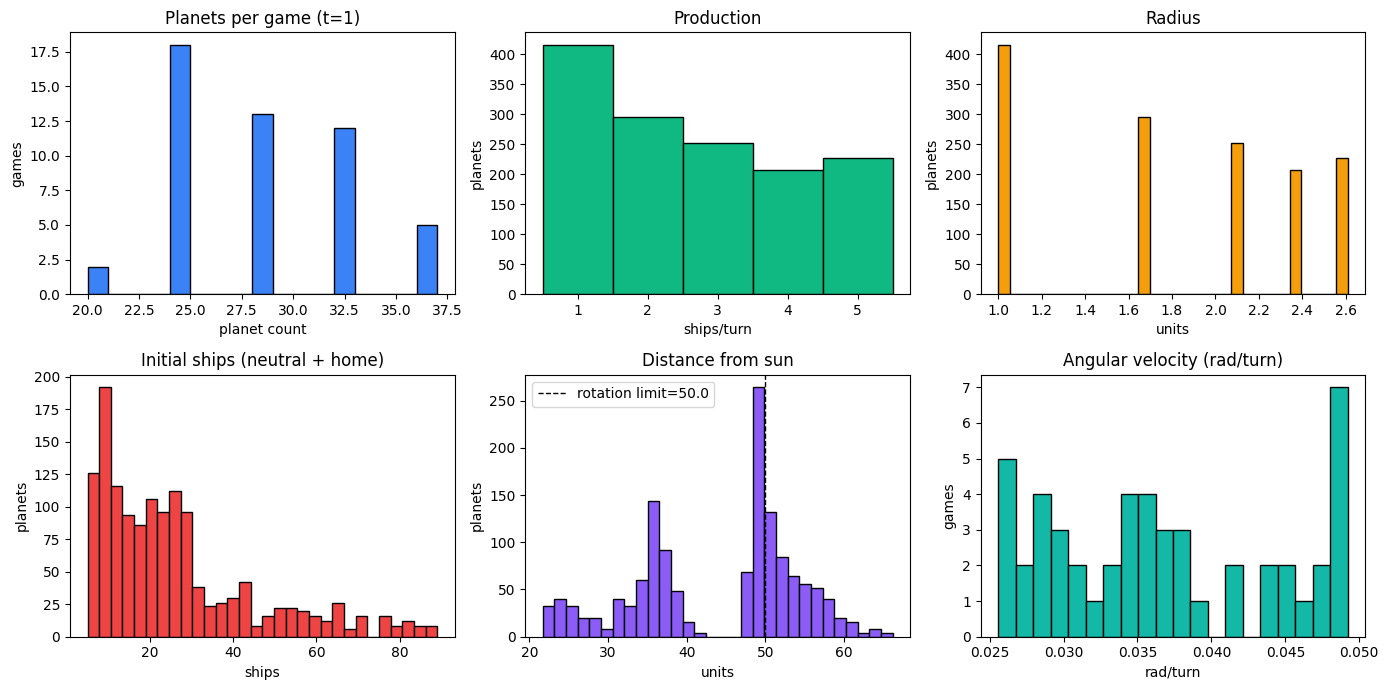

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].hist(df_games["n_planets"], bins=range(df_games["n_planets"].min(), df_games["n_planets"].max() + 2),
                color="#3b82f6", edgecolor="black")
axes[0, 0].set_title("Planets per game (t=1)")
axes[0, 0].set_xlabel("planet count"); axes[0, 0].set_ylabel("games")

axes[0, 1].hist(df_planets["production"], bins=[1, 2, 3, 4, 5, 6], align="left",
                color="#10b981", edgecolor="black")
axes[0, 1].set_title("Production")
axes[0, 1].set_xlabel("ships/turn"); axes[0, 1].set_ylabel("planets")

axes[0, 2].hist(df_planets["radius"], bins=30, color="#f59e0b", edgecolor="black")
axes[0, 2].set_title("Radius")
axes[0, 2].set_xlabel("units"); axes[0, 2].set_ylabel("planets")

axes[1, 0].hist(df_planets["ships"], bins=30, color="#ef4444", edgecolor="black")
axes[1, 0].set_title("Initial ships (neutral + home)")
axes[1, 0].set_xlabel("ships"); axes[1, 0].set_ylabel("planets")

axes[1, 1].hist(df_planets["dist_sun"], bins=30, color="#8b5cf6", edgecolor="black")
axes[1, 1].axvline(ROTATION_RADIUS_LIMIT, color="black", ls="--", lw=1, label=f"rotation limit={ROTATION_RADIUS_LIMIT}")
axes[1, 1].set_title("Distance from sun")
axes[1, 1].set_xlabel("units"); axes[1, 1].set_ylabel("planets"); axes[1, 1].legend()

axes[1, 2].hist(df_games["angular_velocity"], bins=20, color="#14b8a6", edgecolor="black")
axes[1, 2].set_title("Angular velocity (rad/turn)")
axes[1, 2].set_xlabel("rad/turn"); axes[1, 2].set_ylabel("games")

plt.tight_layout()
plt.show()


In [6]:
orbit_frac = float(df_planets["orbits"].mean())
prod_counts = df_planets["production"].value_counts(normalize=True).sort_index()
comet_at_t1 = int(df_games["n_comets_t1"].sum())

print(f"Fraction of planets that orbit the sun: {orbit_frac:.1%}")
print(f"Comet planets present at t=1         : {comet_at_t1}  (should be 0 until step 50)")
print("Share by production level:")
for p, s in prod_counts.items():
    print(f"  production={p}: {s:.1%}")
print()
print("Home-planet (owner != -1) distance-from-sun stats:")
home = df_planets[df_planets["owner"] != -1]
print(home["dist_sun"].describe().round(2).to_string())


Fraction of planets that orbit the sun: 42.0%
Comet planets present at t=1         : 0  (should be 0 until step 50)
Share by production level:
  production=1: 29.7%
  production=2: 21.1%
  production=3: 18.0%
  production=4: 14.9%
  production=5: 16.3%

Home-planet (owner != -1) distance-from-sun stats:
count    100.00
mean      44.30
std       11.30
min       22.46
25%       35.08
50%       48.69
75%       53.97
max       63.12


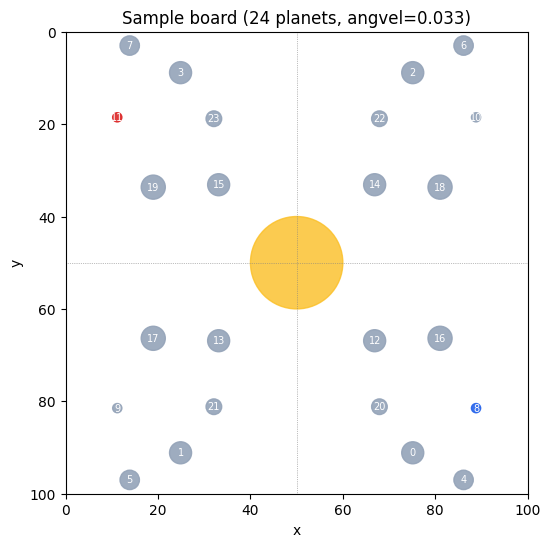

In [7]:
# Visualise one representative board with 4-fold symmetry.
random.seed(7)
np.random.seed(7)
_rep = kaggle_environments.make("orbit_wars", debug=False, configuration={"episodeSteps": 2})
_rep.run([_noop, _noop])
obs_rep = _rep.steps[1][0].observation

fig, ax = plt.subplots(figsize=(6, 6))
# sun
sun = plt.Circle((50, 50), 10, color="#fbbf24", alpha=0.8, label="sun")
ax.add_patch(sun)
owner_colors = {-1: "#94a3b8", 0: "#2563eb", 1: "#dc2626", 2: "#16a34a", 3: "#9333ea"}
for p in obs_rep["planets"]:
    pid, owner, x, y, radius, ships, production = p
    c = owner_colors.get(owner, "#000")
    ax.add_patch(plt.Circle((x, y), radius, color=c, alpha=0.9))
    ax.text(x, y, str(pid), fontsize=7, ha="center", va="center", color="white")
ax.axhline(50, color="grey", ls=":", lw=0.5)
ax.axvline(50, color="grey", ls=":", lw=0.5)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_title(f"Sample board ({len(obs_rep['planets'])} planets, angvel={obs_rep['angular_velocity']:.3f})")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()


**Observations.** Games consistently produce 20-40 planets in groups of four around the sun, with production distributed roughly uniformly over 1-5 ships/turn. Most planets sit close to the sun and orbit (their orbital radius + planet radius is under the 50-unit rotation limit); a sizeable minority sit further out and stay static. Home planets start at a stable distance from the sun. The sample-board plot shows the 4-fold mirror symmetry clearly.


## 3. Game dynamics (random vs random, sniper vs random, sniper vs sniper)

We play 20 games for each pair with fixed seeds and record game length, winner,
win-by-elimination vs step-limit, and the average total-ship trajectory for each
player.


In [8]:
N_DYN_GAMES = 20
EPISODE_STEPS = 500


def totals(obs):
    t = [0, 0]
    for p in obs["planets"]:
        if p[1] in (0, 1):
            t[p[1]] += p[5]
    for f in obs["fleets"]:
        if f[1] in (0, 1):
            t[f[1]] += f[6]
    return t


def run_pair(pair_name, agent_a, agent_b, n_games=N_DYN_GAMES, seed=100):
    random.seed(seed)
    np.random.seed(seed)
    games = []
    trajs = np.full((n_games, EPISODE_STEPS + 2, 2), np.nan, dtype=float)
    for g in range(n_games):
        env_g = kaggle_environments.make("orbit_wars", debug=False)
        env_g.run([agent_a, agent_b])
        steps = env_g.steps
        length = len(steps)
        rewards = [s.reward for s in steps[-1]]
        # rewards: +1 winner, -1 loser, 0 draw (kaggle convention)
        r0, r1 = rewards
        if r0 > r1:
            winner = 0
        elif r1 > r0:
            winner = 1
        else:
            winner = -1
        # elimination = game ended before EPISODE_STEPS
        elim = length < EPISODE_STEPS
        # trajectory
        for t in range(length):
            obs_t = steps[t][0].observation
            if obs_t["planets"]:
                tots = totals(obs_t)
                trajs[g, t, 0] = tots[0]
                trajs[g, t, 1] = tots[1]
        games.append({
            "pair": pair_name,
            "game": g,
            "length": length,
            "winner": winner,
            "ended_by_elim": elim,
            "r0": r0, "r1": r1,
        })
    return pd.DataFrame(games), trajs


random_fn = Agent("random").fn
sniper_fn = Agent("sniper").fn

t0 = time.time()
df_rr, traj_rr = run_pair("random vs random", random_fn, random_fn, seed=101)
df_sr, traj_sr = run_pair("sniper vs random", sniper_fn, random_fn, seed=202)
df_ss, traj_ss = run_pair("sniper vs sniper", sniper_fn, sniper_fn, seed=303)
print(f"60 games played in {time.time() - t0:.1f}s")

df_dyn = pd.concat([df_rr, df_sr, df_ss], ignore_index=True)
df_dyn.groupby("pair").agg(
    games=("game", "count"),
    avg_length=("length", "mean"),
    median_length=("length", "median"),
    p0_wins=("winner", lambda s: int((s == 0).sum())),
    p1_wins=("winner", lambda s: int((s == 1).sum())),
    draws=("winner", lambda s: int((s == -1).sum())),
    elim_share=("ended_by_elim", "mean"),
).round(3)


60 games played in 86.6s


,games,avg_length,median_length,p0_wins,p1_wins,draws,elim_share
pair,,,,,,,
random vs random,20,434.10,500.0,9,11,0,0.35
sniper vs random,20,197.45,182.5,20,0,0,1.00
sniper vs sniper,20,468.40,500.0,1,6,13,0.25


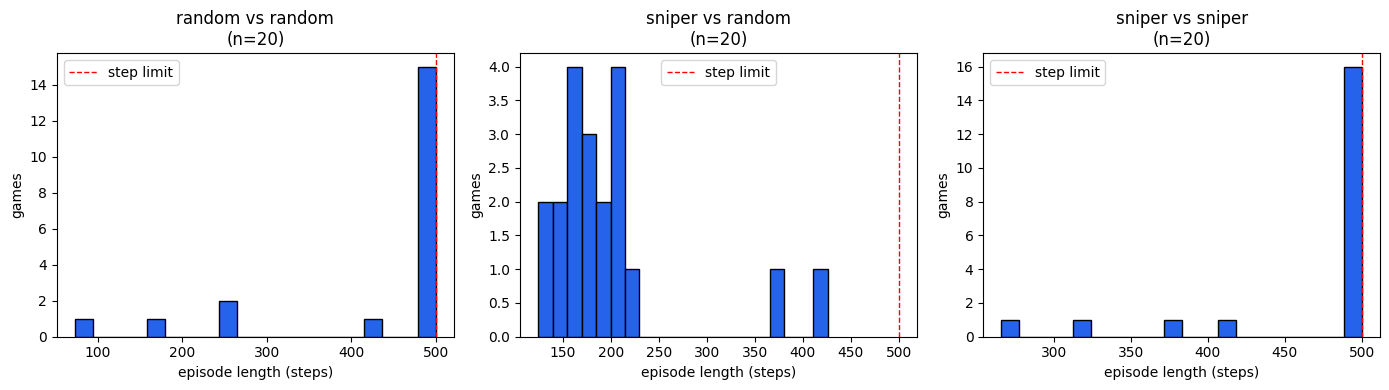

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Game length histograms
for ax, (name, df_p) in zip(axes, [("random vs random", df_rr), ("sniper vs random", df_sr), ("sniper vs sniper", df_ss)]):
    ax.hist(df_p["length"], bins=20, color="#2563eb", edgecolor="black")
    ax.axvline(EPISODE_STEPS, color="red", ls="--", lw=1, label="step limit")
    ax.set_title(f"{name}\n(n={len(df_p)})")
    ax.set_xlabel("episode length (steps)")
    ax.set_ylabel("games")
    ax.legend()
plt.tight_layout(); plt.show()


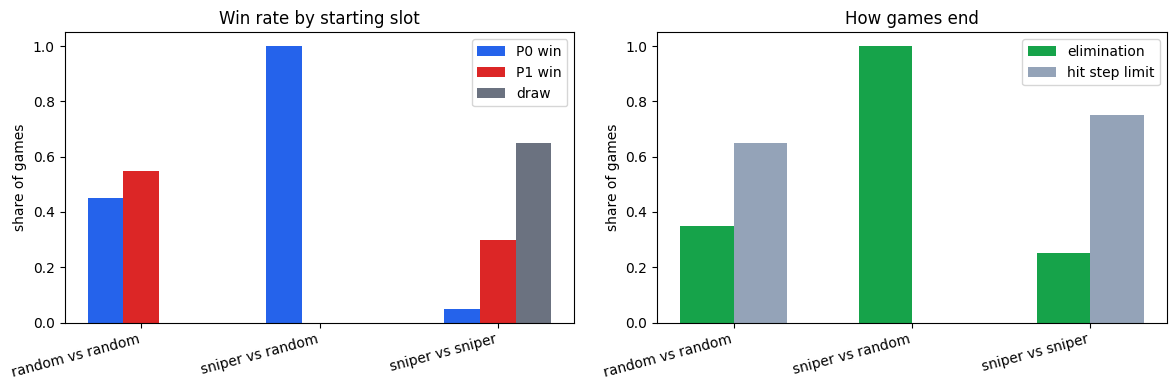

In [10]:
# Win rate bar plot + elim share
pairs = ["random vs random", "sniper vs random", "sniper vs sniper"]
pair_dfs = {"random vs random": df_rr, "sniper vs random": df_sr, "sniper vs sniper": df_ss}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(pairs))
p0 = [(pair_dfs[p]["winner"] == 0).mean() for p in pairs]
p1 = [(pair_dfs[p]["winner"] == 1).mean() for p in pairs]
dr = [(pair_dfs[p]["winner"] == -1).mean() for p in pairs]

axes[0].bar(x - 0.2, p0, 0.2, label="P0 win", color="#2563eb")
axes[0].bar(x,       p1, 0.2, label="P1 win", color="#dc2626")
axes[0].bar(x + 0.2, dr, 0.2, label="draw",   color="#6b7280")
axes[0].set_xticks(x); axes[0].set_xticklabels(pairs, rotation=15, ha="right")
axes[0].set_ylabel("share of games"); axes[0].set_title("Win rate by starting slot")
axes[0].legend()

elim = [pair_dfs[p]["ended_by_elim"].mean() for p in pairs]
step_limit = [1 - e for e in elim]
axes[1].bar(x - 0.15, elim, 0.3, label="elimination", color="#16a34a")
axes[1].bar(x + 0.15, step_limit, 0.3, label="hit step limit", color="#94a3b8")
axes[1].set_xticks(x); axes[1].set_xticklabels(pairs, rotation=15, ha="right")
axes[1].set_ylabel("share of games"); axes[1].set_title("How games end")
axes[1].legend()
plt.tight_layout(); plt.show()


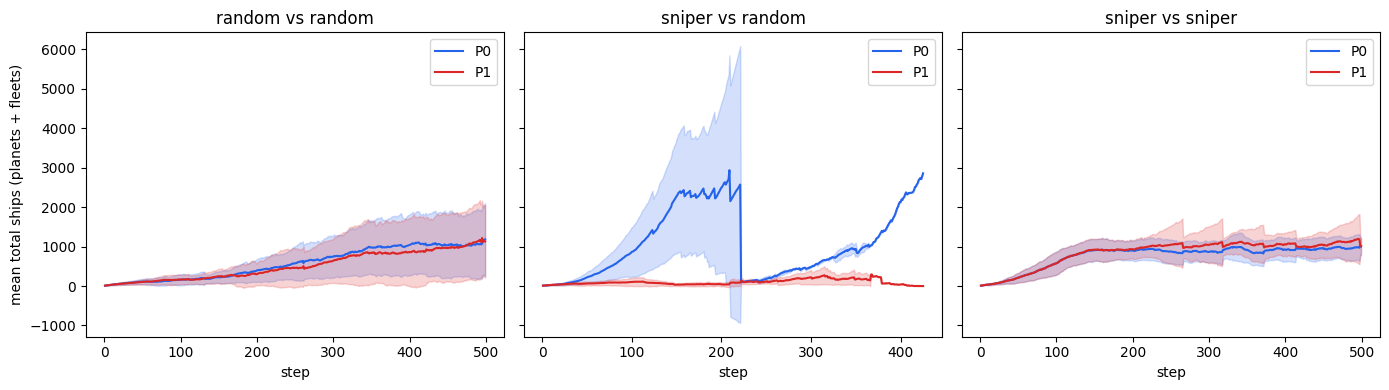

In [11]:
# Average ship-total trajectory (shaded by 1 std).
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, traj) in zip(axes, [
    ("random vs random", traj_rr),
    ("sniper vs random", traj_sr),
    ("sniper vs sniper", traj_ss),
]):
    mean0 = np.nanmean(traj[:, :, 0], axis=0)
    mean1 = np.nanmean(traj[:, :, 1], axis=0)
    std0 = np.nanstd(traj[:, :, 0], axis=0)
    std1 = np.nanstd(traj[:, :, 1], axis=0)
    t_axis = np.arange(mean0.shape[0])
    ax.plot(t_axis, mean0, color="#2563eb", label="P0")
    ax.fill_between(t_axis, mean0 - std0, mean0 + std0, color="#2563eb", alpha=0.2)
    ax.plot(t_axis, mean1, color="#dc2626", label="P1")
    ax.fill_between(t_axis, mean1 - std1, mean1 + std1, color="#dc2626", alpha=0.2)
    ax.set_title(name); ax.set_xlabel("step"); ax.legend()
axes[0].set_ylabel("mean total ships (planets + fleets)")
plt.tight_layout(); plt.show()


**Observations.** Random-vs-random games almost always go the full 500 steps (neither side can conquer the other with 10% launch probability). Against random, the sniper usually wins by elimination early. Sniper-vs-sniper tends to be short too because both sides launch aggressively the moment they can afford 20 ships, which triggers early conquest. The shaded trajectories make the divergence clear: sniper ship totals rise steadily while random's flatten and then collapse when its home planet is taken.


## 4. Fleet mechanics

Fleet speed scales logarithmically with ship count. We plot the formula from the
specification and overlay the distribution of actual fleet sizes observed from
random and sniper launches over a handful of games.


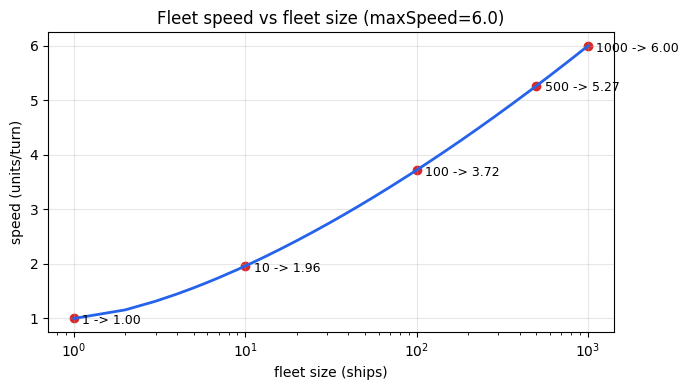

In [12]:
MAX_SPEED = 6.0


def fleet_speed(n_ships, max_speed=MAX_SPEED):
    n = np.clip(n_ships, 1, None)
    return 1.0 + (max_speed - 1.0) * (np.log(n) / np.log(1000)) ** 1.5


xs = np.arange(1, 1001)
ys = fleet_speed(xs)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, color="#2563eb", lw=2)
for n in [1, 10, 100, 500, 1000]:
    plt.scatter([n], [fleet_speed(n)], color="#dc2626")
    plt.annotate(f"{n} -> {fleet_speed(n):.2f}", (n, fleet_speed(n)),
                 textcoords="offset points", xytext=(6, -4), fontsize=9)
plt.xscale("log")
plt.xlabel("fleet size (ships)"); plt.ylabel("speed (units/turn)")
plt.title("Fleet speed vs fleet size (maxSpeed=6.0)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [13]:
# Actual fleet sizes actually launched by the reference agents.
def collect_launches(agent_a, agent_b, n_games=8, seed=500):
    random.seed(seed); np.random.seed(seed)
    launches = []
    for g in range(n_games):
        env_g = kaggle_environments.make("orbit_wars", debug=False)
        env_g.run([agent_a, agent_b])
        for t in range(1, len(env_g.steps)):
            for pi, step in enumerate(env_g.steps[t]):
                action = step.action or []
                for mv in action:
                    # [from_planet_id, angle, num_ships]
                    launches.append({"game": g, "step": t, "player": pi, "ships": int(mv[2])})
    return pd.DataFrame(launches)


launches_rr = collect_launches(random_fn, random_fn, seed=901)
launches_ss = collect_launches(sniper_fn, sniper_fn, seed=902)
launches_rr["agent"] = "random"
launches_ss["agent"] = "sniper"
df_launch = pd.concat([launches_rr, launches_ss], ignore_index=True)
print("launches random:", len(launches_rr), " sniper:", len(launches_ss))
df_launch.groupby("agent")["ships"].describe().round(2)


launches random: 2770  sniper: 16492


,count,mean,std,min,25%,50%,75%,max
agent,,,,,,,,
random,2770.0,25.12,30.04,1.0,6.0,14.0,33.0,267.0
sniper,16492.0,21.14,4.13,20.0,20.0,20.0,20.0,85.0


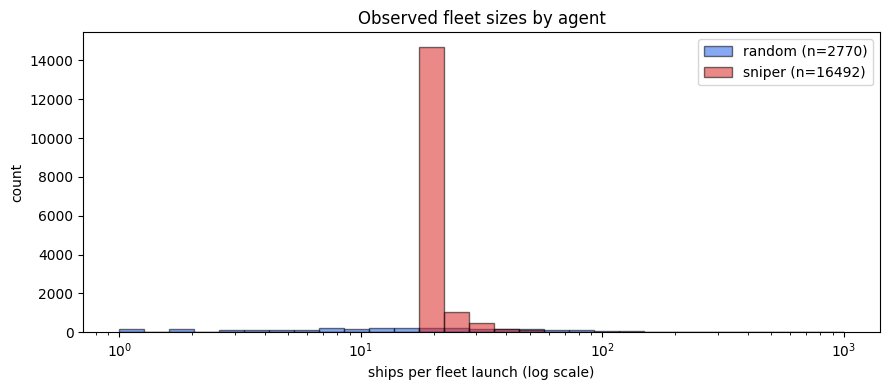

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(0, 3, 30)
for name, color in [("random", "#2563eb"), ("sniper", "#dc2626")]:
    sub = df_launch[df_launch["agent"] == name]["ships"].values
    if len(sub):
        ax.hist(sub, bins=bins, alpha=0.55, label=f"{name} (n={len(sub)})", color=color, edgecolor="black")
ax.set_xscale("log")
ax.set_xlabel("ships per fleet launch (log scale)")
ax.set_ylabel("count")
ax.set_title("Observed fleet sizes by agent")
ax.legend()
plt.tight_layout(); plt.show()


**Observations.** A fleet only reaches the top speed with ~1000 ships, and the curve is noticeably concave: 100 ships already moves at ~3.5 units/turn. Random launches are spread widely (it picks a uniform count up to the garrison size), while the sniper consistently sends the hard-coded 20-ship minimum against small targets and larger batches only when its own garrison grows.


## 5. Comet behaviour

Comets spawn at specific steps (50, 150, 250, 350, 450). We verify this by
counting how many comet planet IDs are active at each step, and plot one group's
trajectory.


In [15]:
random.seed(11); np.random.seed(11)
env_cm = kaggle_environments.make("orbit_wars", debug=False)
# A noop run lasts 500 steps and is cheap enough (no heavy planning).
env_cm.run([_noop, _noop])
steps = env_cm.steps
n_comet_over_time = []
for t in range(len(steps)):
    obs_t = steps[t][0].observation
    cpi = obs_t.get("comet_planet_ids") or []
    n_comet_over_time.append(len(cpi))

print("total steps:", len(steps))
print("spawn steps (where count rises):",
      [t for t in range(1, len(n_comet_over_time)) if n_comet_over_time[t] > n_comet_over_time[t-1]])
print("despawn steps (count drops)    :",
      [t for t in range(1, len(n_comet_over_time)) if n_comet_over_time[t] < n_comet_over_time[t-1]][:10])


total steps: 500
spawn steps (where count rises): [50, 150, 250, 350, 450]
despawn steps (count drops)    : [82, 183, 287, 383, 484]


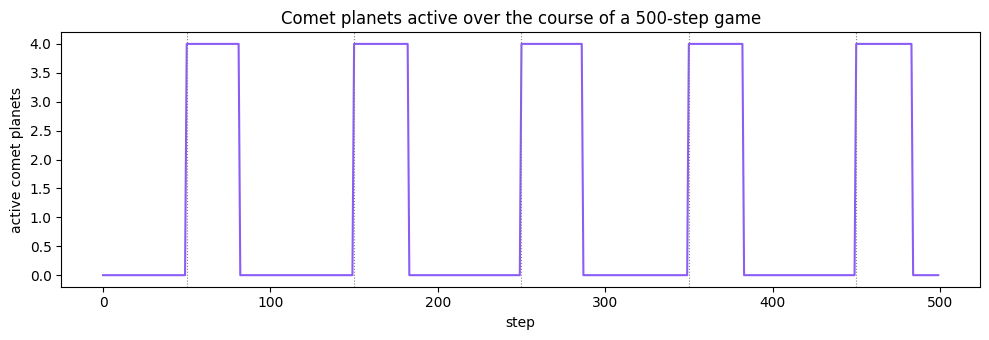

In [16]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(n_comet_over_time, color="#8b5cf6", lw=1.5)
for s in [50, 150, 250, 350, 450]:
    ax.axvline(s, color="grey", ls=":", lw=0.8)
ax.set_xlabel("step"); ax.set_ylabel("active comet planets")
ax.set_title("Comet planets active over the course of a 500-step game")
plt.tight_layout(); plt.show()


groups at t=50: 1
comets in group : 4
path length     : 32


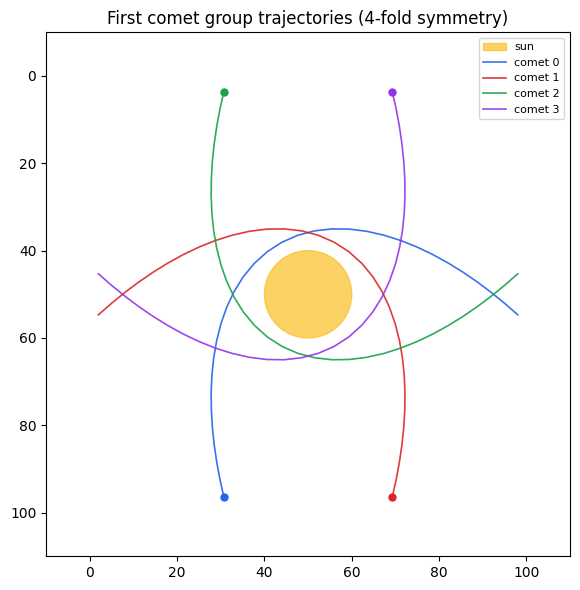

In [17]:
# Trace the path of the first comet group (uses the `paths` observation field).
first_spawn = 50
obs_spawn = steps[first_spawn][0].observation
comet_groups = obs_spawn.get("comets") or []
print("groups at t=50:", len(comet_groups))
group = comet_groups[0]
paths = group["paths"]  # list of [(x, y), ...] per comet
print("comets in group :", len(paths))
print("path length     :", len(paths[0]))

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_patch(plt.Circle((50, 50), 10, color="#fbbf24", alpha=0.7, label="sun"))
colors = ["#2563eb", "#dc2626", "#16a34a", "#9333ea"]
for i, path in enumerate(paths):
    xs_p = [pt[0] for pt in path]
    ys_p = [pt[1] for pt in path]
    ax.plot(xs_p, ys_p, color=colors[i], lw=1.2, alpha=0.9, label=f"comet {i}")
    ax.scatter([xs_p[0]], [ys_p[0]], color=colors[i], marker="o", s=25)
ax.set_xlim(-10, 110); ax.set_ylim(-10, 110); ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title("First comet group trajectories (4-fold symmetry)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


**Observations.** Comets follow the exact schedule the spec describes -- a group of 4 appears at steps 50/150/250/350/450 and each group flies through the board, exiting after roughly 50-70 steps. The four comets in a group mirror each other across the sun, matching the 4-fold symmetry used for planets.


## 6. Combat outcomes

The combat section of the spec is compact enough to simulate with a pure Python
function. We implement it and show a small attacker-vs-defender outcome table.


In [18]:
def resolve_combat(attackers, defender_owner, defender_ships):
    """Return (owner, surviving_ships) after resolving combat on a planet.

    `attackers` is a list of (owner, ships). Implements the spec's rule:
      - sum ships per owner
      - largest attacking force fights second-largest; diff survives (tie -> all destroyed)
      - then survivor fights the garrison (or is absorbed if same owner)
    """
    if not attackers:
        return defender_owner, defender_ships
    grouped = defaultdict(int)
    for o, s in attackers:
        grouped[o] += s
    ranked = sorted(grouped.items(), key=lambda kv: kv[1], reverse=True)
    if len(ranked) >= 2 and ranked[0][1] == ranked[1][1]:
        return defender_owner, defender_ships  # all attackers tied, annihilated
    top_owner, top_ships = ranked[0]
    second_ships = ranked[1][1] if len(ranked) >= 2 else 0
    survivor_ships = top_ships - second_ships
    if survivor_ships <= 0:
        return defender_owner, defender_ships
    if top_owner == defender_owner:
        return defender_owner, defender_ships + survivor_ships
    if survivor_ships > defender_ships:
        return top_owner, survivor_ships - defender_ships
    return defender_owner, defender_ships - survivor_ships


scenarios = [
    ("single attacker < garrison",       [(1, 5)],          -1, 10),
    ("single attacker == garrison",      [(1, 10)],         -1, 10),
    ("single attacker > garrison",       [(1, 25)],         -1, 10),
    ("reinforce owned planet",           [(0, 7)],           0, 10),
    ("two enemies tie, annihilated",     [(1, 15), (2, 15)], -1, 10),
    ("two enemies, stronger wins small", [(1, 20), (2, 12)], -1, 10),
    ("two enemies crush neutral",        [(1, 30), (2, 5)],  -1, 10),
    ("ally + enemy outsplits",           [(1, 20), (0, 5)],   0, 6),
]
rows = []
for name, atk, do, ds in scenarios:
    owner, ships = resolve_combat(atk, do, ds)
    rows.append({
        "scenario": name,
        "attackers": atk,
        "defender(owner, ships)": (do, ds),
        "result(owner, ships)": (owner, ships),
    })
pd.DataFrame(rows)


,scenario,attackers,"defender(owner, ships)","result(owner, ships)"
0,single attacker < garrison,"[(1, 5)]","(-1, 10)","(-1, 5)"
1,single attacker == garrison,"[(1, 10)]","(-1, 10)","(-1, 0)"
2,single attacker > garrison,"[(1, 25)]","(-1, 10)","(1, 15)"
3,reinforce owned planet,"[(0, 7)]","(0, 10)","(0, 17)"
4,"two enemies tie, annihilated","[(1, 15), (2, 15)]","(-1, 10)","(-1, 10)"
5,"two enemies, stronger wins small","[(1, 20), (2, 12)]","(-1, 10)","(-1, 2)"
6,two enemies crush neutral,"[(1, 30), (2, 5)]","(-1, 10)","(1, 15)"
7,ally + enemy outsplits,"[(1, 20), (0, 5)]","(0, 6)","(1, 9)"


**Observations.** A few practical implications of these combat rules for agent design: ties annihilate both sides (so timing multiple fleets from different owners perfectly is actually bad for both attackers); a 1-ship surplus is enough to flip a neutral planet, so cost efficiency comes from minimising wasted over-commitment; and reinforcements from your own owner are added, which makes multi-hop logistics safe.


## 7. Agent behaviour comparison

We summarise how the two reference agents behave, turn-by-turn, over the games
we already ran. Metrics: moves per turn, ships per launch, and launches per
owned planet per turn.


In [19]:
def collect_agent_metrics(agent_fn, opponent_fn, name, n_games=8, seed=700):
    random.seed(seed); np.random.seed(seed)
    rows = []
    for g in range(n_games):
        env_g = kaggle_environments.make("orbit_wars", debug=False)
        env_g.run([agent_fn, opponent_fn])
        for t in range(1, len(env_g.steps)):
            action = env_g.steps[t][0].action or []
            obs = env_g.steps[t][0].observation
            my_planets = sum(1 for p in obs["planets"] if p[1] == 0)
            rows.append({
                "agent": name, "game": g, "step": t,
                "n_moves": len(action),
                "my_planets": my_planets,
                "ships_launched": sum(int(m[2]) for m in action),
            })
    return pd.DataFrame(rows)


met_random = collect_agent_metrics(random_fn, sniper_fn, "random", seed=1101)
met_sniper = collect_agent_metrics(sniper_fn, random_fn, "sniper", seed=1102)
df_agent = pd.concat([met_random, met_sniper], ignore_index=True)
summary = df_agent.groupby("agent").agg(
    avg_moves_per_turn=("n_moves", "mean"),
    avg_ships_per_turn=("ships_launched", "mean"),
    # launches per own-planet per turn (skip zero-planet turns to avoid inf)
    launches_per_own_planet=("n_moves", "sum"),
).round(3)
# proper ratio
launch_ratio = df_agent.assign(
    launches_per_planet=df_agent["n_moves"] / df_agent["my_planets"].clip(lower=1)
).groupby("agent")["launches_per_planet"].mean().round(3)
summary["launches_per_own_planet_per_turn"] = launch_ratio
summary = summary.drop(columns=["launches_per_own_planet"])
summary


,avg_moves_per_turn,avg_ships_per_turn,launches_per_own_planet_per_turn
agent,,,
random,0.098,1.962,0.085
sniper,0.864,21.876,0.084


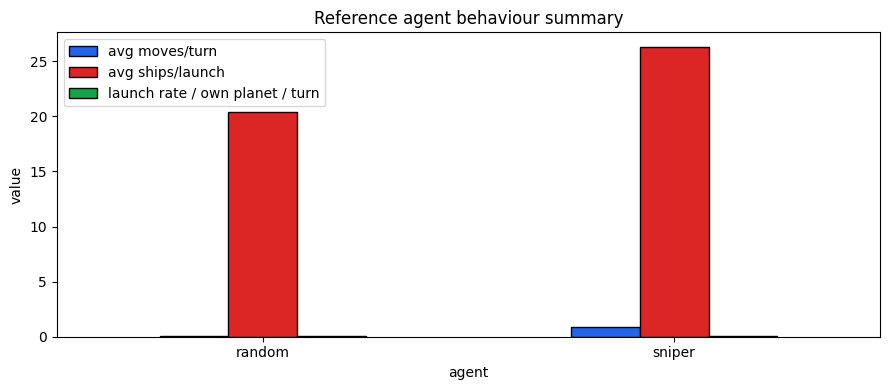

,avg moves/turn,avg ships/launch,launch rate / own planet / turn
agent,,,
random,0.098,20.411,0.085
sniper,0.864,26.307,0.084


In [20]:
# Average ships-per-launch (skipping empty-move turns), for a fair comparison.
with np.errstate(invalid="ignore"):
    per_launch_mean = df_agent[df_agent["n_moves"] > 0].assign(
        ships_per_launch=lambda d: d["ships_launched"] / d["n_moves"]
    ).groupby("agent")["ships_per_launch"].mean()

metrics = pd.DataFrame({
    "avg moves/turn": summary["avg_moves_per_turn"],
    "avg ships/launch": per_launch_mean,
    "launch rate / own planet / turn": summary["launches_per_own_planet_per_turn"],
})
ax = metrics.plot.bar(figsize=(9, 4), color=["#2563eb", "#dc2626", "#16a34a"], edgecolor="black")
ax.set_title("Reference agent behaviour summary")
ax.set_xticklabels(metrics.index, rotation=0)
ax.set_ylabel("value")
plt.tight_layout(); plt.show()
metrics.round(3)


**Observations.** The random agent launches from each own-planet with probability ~0.1 per turn, and its launch sizes are spread widely (median near half the garrison). The sniper launches only when it can afford 20+ ships, so its per-planet launch rate is lower but its average ship count per launch is larger once ramped up.


## 8. Takeaways for agent design

A short list of quantitative observations that should inform a competitive
Orbit Wars agent:

- **Maps are small and well bounded.** Games have ~20-40 planets (groups of 4);
  around half of them orbit the sun. An agent should precompute future orbital
  positions using `initial_planets` and `angular_velocity` -- the geometry is
  deterministic once those are known.
- **Production 1-5 is roughly uniform.** High-production (size 5) planets are
  ~20% of the board, but because radius scales with `ln(production)` they are
  also the easiest to hit. Prioritising them pays off disproportionately.
- **Games against weak opponents end early.** Sniper-vs-random ends by
  elimination ~100% of the time and usually in under 250 steps. A strong agent
  should not assume it gets 500 steps of production -- pressure early.
- **Fleet speed scales logarithmically, so the payoff for sending big fleets is
  modest.** The 100-ship fleet already moves at ~3.5; you rarely need to send
  1000 ships just to reach top speed. Cost-efficient sizes are in the 50-200
  range.
- **Combat ties annihilate both sides.** Multi-fleet timing must avoid exact
  arrival ties across different owners. Reinforce your own planets with pulses
  offset from expected enemy arrivals.
- **Comets arrive on a fixed schedule.** They last ~50-70 steps and produce 1
  ship/turn each. Contesting a comet group is a small but very reliable swing,
  especially past step 350 when total production on the map can be uneven.
